<a href="https://colab.research.google.com/github/dndx1/ABSENSI-PT.-FLASNOMS-/blob/main/Analisis_Sentimen_Hustle_Culture_dan_Quiet_Quitting_pada_Komentar_Twitter_Berbahasa_Indonesia_Menggunakan_TF_IDF_dengan_Algoritma_SVM_dan_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install Sastrawi -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 7.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import re
import string

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [ ]:
hustle = pd.read_excel(
    '/content/drive/MyDrive/#TA 1/Budaya Kerja (Work-Life Balance): Analisis percakapan tentang fenomena "hustle culture" vs "quiet quitting" di kalangan pekerja muda di platform seperti LinkedIn atau X./part 2/hustle culture.xlsx'
)

quiet = pd.read_excel(
    '/content/drive/MyDrive/#TA 1/Budaya Kerja (Work-Life Balance): Analisis percakapan tentang fenomena "hustle culture" vs "quiet quitting" di kalangan pekerja muda di platform seperti LinkedIn atau X./part 2/Quite Quitting.xlsx'
)

In [ ]:
print(hustle.shape)
print(quiet.shape)

hustle.head()

(20003, 17)
(20009, 32)


,id,url,text,createdAt,author.profilePicture,retweetCount,replyCount,likeCount,quoteCount,viewCount,bookmarkCount,source,lang,isReply,isRetweet,isQuote,isPinned
0,2064213350033072518,https://x.com/okubio_eric/status/2064213350033...,Unpopular truth:\nA lot of “hustle culture” is...,Tue Jun 09 05:09:48 +0000 2026,https://pbs.twimg.com/profile_images/206419900...,0,1,0,0,0,0,NaN,en,True,NaN,NaN,False
1,2064201067722834040,https://x.com/mejiahombre1601/status/206420106...,2025: The year we break free from hustle cultu...,Tue Jun 09 04:21:00 +0000 2026,https://pbs.twimg.com/profile_images/200028344...,0,0,0,0,1,0,NaN,en,False,NaN,NaN,False
2,2064188718383079578,https://x.com/BradLavallee/status/206418871838...,@Jayde8700 We already know this. Fight the pow...,Tue Jun 09 03:31:55 +0000 2026,https://pbs.twimg.com/profile_images/148126395...,0,0,0,0,1,0,NaN,en,True,NaN,NaN,False
3,2064178434398683383,https://x.com/nishaanth_bala/status/2064178434...,Much of bangerlore hate is from the 3rd catego...,Tue Jun 09 02:51:03 +0000 2026,https://pbs.twimg.com/profile_images/203785009...,0,0,0,0,24,0,NaN,en,False,NaN,True,False
4,2064168443004252486,https://x.com/imfaisii/status/2064168443004252486,Hustle culture didn't die.\nIt rebranded as 's...,Tue Jun 09 02:11:21 +0000 2026,https://pbs.twimg.com/profile_images/191111889...,0,0,0,0,3,0,NaN,en,False,NaN,NaN,False


In [ ]:
print(hustle.columns)
print(quiet.columns)

Index(['id', 'url', 'text', 'createdAt', 'author.profilePicture',
       'retweetCount', 'replyCount', 'likeCount', 'quoteCount', 'viewCount',
       'bookmarkCount', 'source', 'lang', 'isReply', 'isRetweet', 'isQuote',
       'isPinned'],
      dtype='object')
Index(['type', 'id', 'url', 'twitterUrl', 'text', 'source', 'retweetCount',
       'replyCount', 'likeCount', 'quoteCount', 'viewCount', 'createdAt',
       'lang', 'bookmarkCount', 'isReply', 'inReplyToId', 'conversationId',
       'inReplyToUserId', 'inReplyToUsername', 'isPinned', 'author',
       'extendedEntities', 'card', 'place', 'entities',
       'reply_to_user_results', 'quoted_tweet_results', 'quoted_tweet',
       'retweeted_tweet', 'isConversationControlled', 'searchTermIndex',
       'isQuote'],
      dtype='object')


In [ ]:
print(hustle['lang'].unique())

['en' 'fr' 'und' 'in' 'tr' 'sv' 'ja' 'tl' 'hi' 'et' 'ar' 'pt' 'no' 'it'
 'uk' 'fi' 'de' 'ro' 'es' 'cs' 'zh' 'pl' 'el' 'sl' 'ko' 'nl' 'vi' 'th'
 'mr']


In [ ]:
hustle = hustle[hustle['lang'] == 'in']
quiet = quiet[quiet['lang'] == 'in']

print("Hustle:", len(hustle))
print("Quiet:", len(quiet))

Hustle: 10691
Quiet: 10427


In [ ]:
hustle = hustle[['text']]
quiet = quiet[['text']]

In [ ]:
hustle['topic'] = 'Hustle Culture'
quiet['topic'] = 'Quiet Quitting'

In [ ]:
df = pd.concat([hustle, quiet], ignore_index=True)

print(df.shape)
df.head()

(21118, 2)


,text,topic
0,"Market kripto emang buka 24/7, tapi tugas kuli...",Hustle Culture
1,sbnrnya bukan lgi ngejar apa2. emg sie itu ter...,Hustle Culture
2,neoliberal melahirkan hustle culture,Hustle Culture
3,@suirentto Terlalu hustle culture. Bisa kita b...,Hustle Culture
4,Terlihat menenangkan di tengah hustle culture....,Hustle Culture


In [ ]:
print("Sebelum:", len(df))

df.drop_duplicates(subset='text', inplace=True)

print("Sesudah:", len(df))

Sebelum: 21118
Sesudah: 20688


In [ ]:
df.isnull().sum()

,0
text,0
topic,0


In [ ]:
!pip install emoji -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 14.6 MB/s eta 0:00:00


In [ ]:
import re
import emoji

In [ ]:
def clean_text(text):

    text = str(text)

    # lowercase
    text = text.lower()

    # hapus url
    text = re.sub(r'http\S+|www\S+', '', text)

    # hapus mention
    text = re.sub(r'@\w+', '', text)

    # hapus hashtag (#tag -> tag)
    text = re.sub(r'#', '', text)

    # hapus emoji
    text = emoji.replace_emoji(text, replace='')

    # hapus angka
    text = re.sub(r'\d+', '', text)

    # hapus karakter selain huruf
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [ ]:
df['clean_text'] = df['text'].apply(clean_text)

In [ ]:
!pip install Sastrawi -q

In [ ]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

In [ ]:
factory = StopWordRemoverFactory()
stopwords = set(factory.get_stop_words())

In [ ]:
def remove_stopwords(tokens):
    return [word for word in tokens if word not in stopwords]

In [ ]:
df['tokens'] = df['clean_text'].apply(lambda x: x.split())

In [ ]:
df[['clean_text', 'tokens']].head()

,clean_text,tokens
0,market kripto emang buka tapi tugas kuliah onl...,"[market, kripto, emang, buka, tapi, tugas, kul..."
1,sbnrnya bukan lgi ngejar apa emg sie itu terke...,"[sbnrnya, bukan, lgi, ngejar, apa, emg, sie, i..."
2,neoliberal melahirkan hustle culture,"[neoliberal, melahirkan, hustle, culture]"
3,terlalu hustle culture bisa kita bersantai ong...,"[terlalu, hustle, culture, bisa, kita, bersant..."
4,terlihat menenangkan di tengah hustle culture ...,"[terlihat, menenangkan, di, tengah, hustle, cu..."


In [ ]:
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

In [ ]:
factory = StopWordRemoverFactory()
stopwords = set(factory.get_stop_words())

In [ ]:
def remove_stopwords(tokens):
    return [word for word in tokens if word not in stopwords]

In [ ]:
df['tokens_no_stop'] = df['tokens'].apply(remove_stopwords)

In [ ]:
df[['tokens', 'tokens_no_stop']].head()

,tokens,tokens_no_stop
0,"[market, kripto, emang, buka, tapi, tugas, kul...","[market, kripto, emang, buka, tugas, kuliah, o..."
1,"[sbnrnya, bukan, lgi, ngejar, apa, emg, sie, i...","[sbnrnya, bukan, lgi, ngejar, apa, emg, sie, t..."
2,"[neoliberal, melahirkan, hustle, culture]","[neoliberal, melahirkan, hustle, culture]"
3,"[terlalu, hustle, culture, bisa, kita, bersant...","[terlalu, hustle, culture, bersantai, ongkang,..."
4,"[terlihat, menenangkan, di, tengah, hustle, cu...","[terlihat, menenangkan, tengah, hustle, cultur..."


In [ ]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()

In [ ]:
def stemming(tokens):
    return stemmer.stem(' '.join(tokens))

In [ ]:
df['tokens_no_stop'].apply(len).describe()

,tokens_no_stop
count,20688.000000
mean,37.780839
std,58.515276
min,0.000000
25%,20.000000
50%,29.000000
75%,37.000000
max,2635.000000


In [ ]:
df['token_length'] = df['tokens_no_stop'].apply(len)

df.nlargest(5, 'token_length')[['text', 'token_length']]

,text,token_length
13724,[Zaman bekerja] 💼\n\nSetelah lulus sidang skri...,2635
335,Berpikir dan bertindak\nBerpikir dan bertindak...,2392
378,Berpikir dan bertindak\nBerpikir dan bertindak...,2075
14806,Utas 3.\n\nKETENTUAN MENGENAI HAK TENAGA MEDIS...,1636
14805,Utas 3. \n\nKETENTUAN MENGENAI HAK TENAGA MED...,1525


In [ ]:
df['token_length'] = df['tokens_no_stop'].apply(len)

df = df[df['token_length'] <= 100]

In [ ]:
print(df.shape)

df['token_length'].describe()

(19754, 6)


,token_length
count,19754.000000
mean,29.173129
std,14.874918
min,0.000000
25%,20.000000
50%,29.000000
75%,36.000000
max,100.000000


In [ ]:
df = df[df['token_length'] > 0]

print(df.shape)

(19753, 6)


In [ ]:
df['final_text'] = df['tokens_no_stop'].apply(
    lambda x: ' '.join(x)
)

In [ ]:
df[['final_text']].head()

,final_text
0,market kripto emang buka tugas kuliah online d...
1,sbnrnya bukan lgi ngejar apa emg sie terkesan ...
2,neoliberal melahirkan hustle culture
3,terlalu hustle culture bersantai ongkang kaki aja
4,terlihat menenangkan tengah hustle culture jad...


In [ ]:
df.to_csv(
    '/content/drive/MyDrive/#TA 1/Budaya Kerja (Work-Life Balance): Analisis percakapan tentang fenomena "hustle culture" vs "quiet quitting" di kalangan pekerja muda di platform seperti LinkedIn atau X./part 2/dataset_preprocessing.csv',
    index=False
)

In [ ]:
print(df.shape)

df[['final_text']].head()

(19753, 7)


,final_text
0,market kripto emang buka tugas kuliah online d...
1,sbnrnya bukan lgi ngejar apa emg sie terkesan ...
2,neoliberal melahirkan hustle culture
3,terlalu hustle culture bersantai ongkang kaki aja
4,terlihat menenangkan tengah hustle culture jad...


In [ ]:
!pip install requests -q

In [ ]:
import pandas as pd

positive_url = "https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv"
negative_url = "https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv"

positive = pd.read_csv(positive_url, sep='\t')
negative = pd.read_csv(negative_url, sep='\t')

print("Kata positif:", len(positive))
print("Kata negatif:", len(negative))

Kata positif: 3609
Kata negatif: 6609


In [ ]:
positive_words = set(positive['word'].tolist())
negative_words = set(negative['word'].tolist())

In [ ]:
def sentiment_label(text):

    pos_score = 0
    neg_score = 0

    words = text.split()

    for word in words:
        if word in positive_words:
            pos_score += 1

        if word in negative_words:
            neg_score += 1

    if pos_score > neg_score:
        return "Positif"

    elif neg_score > pos_score:
        return "Negatif"

    else:
        return "Netral"

In [ ]:
df['sentiment'] = df['final_text'].apply(sentiment_label)

In [ ]:
df['sentiment'].value_counts()

,count
sentiment,
Positif,12496
Negatif,4855
Netral,2402


In [ ]:
X = df['final_text']
y = df['sentiment']

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X_tfidf = tfidf.fit_transform(X)

print(X_tfidf.shape)

(19753, 5000)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(15802, 5000)
(3951, 5000)


In [ ]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_svm, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred_svm, average='weighted'))

Accuracy : 0.8202986585674513
Precision: 0.7863121756623606
Recall   : 0.8202986585674513
F1 Score : 0.7958320429916791


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_rf, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred_rf, average='weighted'))

Accuracy : 0.7058972412047583
Precision: 0.6985883883548899
Recall   : 0.7058972412047583
F1 Score : 0.641371238030763


In [ ]:
from sklearn.metrics import confusion_matrix

cm_svm = confusion_matrix(y_test, y_pred_svm)

print(cm_svm)

[[ 799   63  109]
 [ 157   73  250]
 [  78   53 2369]]


In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[ 345    4  622]
 [  75   16  389]
 [  67    5 2428]]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

     Negatif       0.77      0.82      0.80       971
      Netral       0.39      0.15      0.22       480
     Positif       0.87      0.95      0.91      2500

    accuracy                           0.82      3951
   macro avg       0.68      0.64      0.64      3951
weighted avg       0.79      0.82      0.80      3951



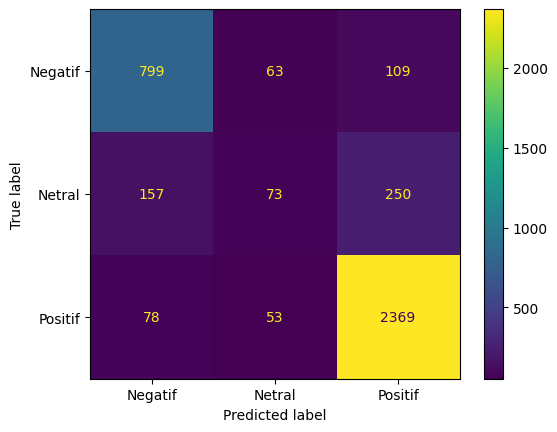

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm
)

plt.show()

In [ ]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

     Negatif       0.71      0.36      0.47       971
      Netral       0.64      0.03      0.06       480
     Positif       0.71      0.97      0.82      2500

    accuracy                           0.71      3951
   macro avg       0.68      0.45      0.45      3951
weighted avg       0.70      0.71      0.64      3951



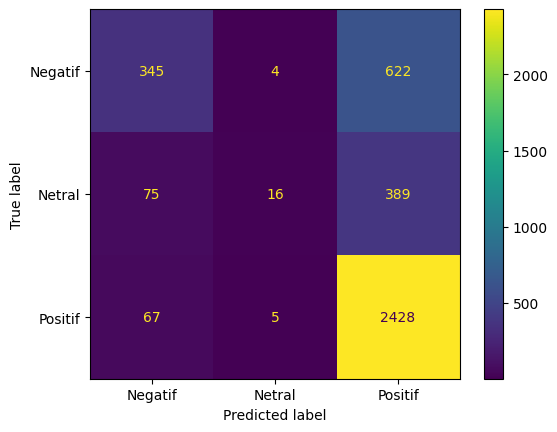

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf
)

plt.show()

In [ ]:
from sklearn.svm import LinearSVC

svm_balanced = LinearSVC(
    class_weight='balanced',
    random_state=42
)

svm_balanced.fit(X_train, y_train)

y_pred_balanced = svm_balanced.predict(X_test)

print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

     Negatif       0.76      0.77      0.76       971
      Netral       0.31      0.29      0.30       480
     Positif       0.89      0.90      0.90      2500

    accuracy                           0.79      3951
   macro avg       0.65      0.65      0.65      3951
weighted avg       0.79      0.79      0.79      3951

